# Entrega 3: Modelo predictivo lineal 
### Detección de Tráfico Malicioso en Redes IoT
**Santiago Vieira Ceballos — Sara Franco Taborda — Sara Medina Molina**

## 1. Preparación de los datos

En esta sección se carga el dataset y se replica la limpieza realizada en la
Entrega 2: eliminación de duplicados, corrección de tipos de datos y descarte
de variables irrelevantes (`src_ip`, `dst_ip` por ser identificadores sin
valor predictivo, y `type` por ser redundante con la variable objetivo `label`).

Posteriormente se separan las características (X) de la variable objetivo (y),
y se realiza la partición en conjuntos de entrenamiento (80%) y prueba (20%)
con `stratify=y` para preservar la proporción de clases dado el desbalance
identificado en la entrega anterior.

Las transformaciones específicas (imputación, escalamiento, codificación) se
implementarán dentro del pipeline en el punto 3 para evitar fuga de datos
durante la validación cruzada.

In [19]:
from pathlib import Path
import pandas as pd
import numpy as np

DATA_DIR = Path().resolve().parent / "Data"
data_file = "train_test_network.csv"
data_path = DATA_DIR / data_file

# Carga del dataset
df = pd.read_csv(data_path, na_values=[' '])
print(f'Dimensiones iniciales: {df.shape}')

# Corrección de tipos: variables que son códigos categóricos pero están como int
df = df.astype({
    'src_port'   : 'object',
    'dst_port'   : 'object',
    'dns_qclass' : 'object',
    'dns_qtype'  : 'object',
    'dns_rcode'  : 'object',
    'label'      : 'object'
})

# Eliminación de duplicados
df = df.drop_duplicates()
print(f'Dimensiones tras eliminar duplicados: {df.shape}')

# Descarte de variables irrelevantes:
# - src_ip y dst_ip son identificadores de red sin valor predictivo
# - type es redundante con label (ambas codifican lo mismo, una binaria y otra multiclase)
df = df.drop(columns=['src_ip', 'dst_ip', 'type'])
print(f'Dimensiones finales: {df.shape}')

df.head()

Dimensiones iniciales: (211043, 44)
Dimensiones tras eliminar duplicados: (190474, 44)
Dimensiones finales: (190474, 41)


,src_port,dst_port,proto,service,duration,src_bytes,dst_bytes,conn_state,missed_bytes,src_pkts,...,http_request_body_len,http_response_body_len,http_status_code,http_user_agent,http_orig_mime_types,http_resp_mime_types,weird_name,weird_addl,weird_notice,label
0,4444,49178,tcp,-,290.371539,101568,2592,OTH,0,108,...,0,0,0,-,-,-,-,-,-,1
1,49180,8080,tcp,-,0.000102,0,0,REJ,0,1,...,0,0,0,-,-,-,-,-,-,1
2,49180,8080,tcp,-,0.000148,0,0,REJ,0,1,...,0,0,0,-,-,-,-,-,-,1
3,49180,8080,tcp,-,0.000113,0,0,REJ,0,1,...,0,0,0,-,-,-,-,-,-,1
4,49180,8080,tcp,-,0.000130,0,0,REJ,0,1,...,0,0,0,-,-,-,-,-,-,1


### Separación de características y variable objetivo

La variable a predecir es `label`, una variable binaria que indica si un flujo
de red es benigno (0) o malicioso (1). Por tratarse de un problema de
clasificación binaria, se utilizará un modelo de **Regresión Logística
regularizada** en el punto 2.

In [20]:
# Separación de características (X) y variable objetivo (y)
X = df.drop(columns=['label'])
y = df['label'].astype(int)  # se convierte a int para el modelo

print(f'Dimensiones de X: {X.shape}')
print(f'Dimensiones de y: {y.shape}')

# Verificación del balance de clases
print('\nDistribución de la variable objetivo:')
print(y.value_counts())
print(f'\nProporción clase minoritaria: {y.value_counts(normalize=True).min():.3f}')

Dimensiones de X: (190474, 40)
Dimensiones de y: (190474,)

Distribución de la variable objetivo:
label
1    148434
0     42040
Name: count, dtype: int64

Proporción clase minoritaria: 0.221


### Partición en entrenamiento y prueba

Se realiza una partición 80/20 con `random_state=42` para garantizar
reproducibilidad. Se utiliza `stratify=y` para que ambos subconjuntos
mantengan la misma proporción de clases que el dataset original, lo cual
es importante dado el desbalance observado.

In [21]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f'Tamaño del conjunto de entrenamiento: {X_train.shape}')
print(f'Tamaño del conjunto de prueba: {X_test.shape}')

# Verificación de la estratificación
print('\nProporción de clases en entrenamiento:')
print(y_train.value_counts(normalize=True))
print('\nProporción de clases en prueba:')
print(y_test.value_counts(normalize=True))

Tamaño del conjunto de entrenamiento: (152379, 40)
Tamaño del conjunto de prueba: (38095, 40)

Proporción de clases en entrenamiento:
label
1    0.779287
0    0.220713
Name: proportion, dtype: float64

Proporción de clases en prueba:
label
1    0.779289
0    0.220711
Name: proportion, dtype: float64


### Identificación de variables numéricas y categóricas

Se identifican los dos tipos de variables presentes en `X_train` para
aplicarles transformaciones independientes en el pipeline del punto 3.
La identificación se hace sobre `X_train` (no sobre `X` completo) para
mantener la separación estricta entre los datos de entrenamiento y prueba.

In [22]:
# Reclasificación de puertos como numéricos para evitar explosión dimensional
# Aunque src_port y dst_port son códigos, su alta cardinalidad (miles de
# valores únicos debido a puertos efímeros) hace inviable la codificación
# OneHot. Los tratamos como numéricos aprovechando que existe una relación
# ordinal parcial entre rangos de puertos (well-known, registered, ephemeral).
X_train = X_train.astype({'src_port': 'int64', 'dst_port': 'int64'})
X_test = X_test.astype({'src_port': 'int64', 'dst_port': 'int64'})

# Identificación de variables numéricas y categóricas
numeric_features = X_train.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = X_train.select_dtypes(include=['object']).columns.tolist()

print(f'Variables numéricas ({len(numeric_features)}):')
print(numeric_features)
print(f'\nVariables categóricas ({len(categorical_features)}):')
print(categorical_features)

Variables numéricas (13):
['src_port', 'dst_port', 'duration', 'src_bytes', 'dst_bytes', 'missed_bytes', 'src_pkts', 'src_ip_bytes', 'dst_pkts', 'dst_ip_bytes', 'http_request_body_len', 'http_response_body_len', 'http_status_code']

Variables categóricas (27):
['proto', 'service', 'conn_state', 'dns_query', 'dns_qclass', 'dns_qtype', 'dns_rcode', 'dns_AA', 'dns_RD', 'dns_RA', 'dns_rejected', 'ssl_version', 'ssl_cipher', 'ssl_resumed', 'ssl_established', 'ssl_subject', 'ssl_issuer', 'http_trans_depth', 'http_method', 'http_uri', 'http_version', 'http_user_agent', 'http_orig_mime_types', 'http_resp_mime_types', 'weird_name', 'weird_addl', 'weird_notice']


## 2. Implementación de un modelo lineal regularizado

La variable a predecir es `label`, una variable **binaria** que indica si un
flujo de red corresponde a tráfico normal (0) o malicioso (1). Por tratarse
de un problema de **clasificación binaria**, el modelo lineal regularizado
adecuado es la **Regresión Logística regularizada** (`LogisticRegression`
de scikit-learn).

A diferencia de los modelos `Ridge` y `Lasso` —que se usan para problemas de
regresión con variable objetivo continua— `LogisticRegression` modela la
probabilidad de pertenencia a una clase mediante la función logística, y
permite aplicar regularización L1, L2 o Elastic Net para controlar la
complejidad del modelo y reducir la varianza.

### Hiperparámetros relevantes

`LogisticRegression` tiene tres hiperparámetros principales para sintonizar:

- **`penalty`**: tipo de regularización aplicada. Puede ser `'l1'`, `'l2'` o
  `'elasticnet'`. La penalización `'l2'` reduce el tamaño de todos los
  coeficientes, mientras que `'l1'` puede llevar coeficientes exactamente a
  cero (selección implícita de características). `'elasticnet'` combina ambas.

- **`C`**: es el inverso del factor de regularización ($C = 1/\lambda$). Puede
  variar en el rango $(0, \infty)$. Mientras **más grande** sea `C`, **menor**
  es la penalización sobre los coeficientes (modelo más complejo); mientras
  **más pequeño**, **mayor** la regularización (modelo más simple).

- **`l1_ratio`**: solo aplica si `penalty='elasticnet'`. Define el peso
  relativo entre L1 y L2.

Para esta entrega se utilizará `penalty='elasticnet'` con el solver `'saga'`,
que soporta los tres tipos de regularización y permite explorar el espacio
completo de hiperparámetros durante la sintonización en el punto 4. Además,
se usará `class_weight='balanced'` para abordar el desbalance de clases
identificado anteriormente.

In [23]:
from sklearn.linear_model import LogisticRegression

# Instanciación del modelo lineal regularizado
# - penalty='elasticnet': permite combinar regularización L1 y L2
# - solver='saga': único solver compatible con elasticnet y datasets grandes
# - class_weight='balanced': ajusta automáticamente los pesos inversamente
#   proporcionales a la frecuencia de cada clase, para manejar el desbalance
# - max_iter=2000: se incrementa para garantizar convergencia
# - random_state=42: para reproducibilidad
# Los hiperparámetros C y l1_ratio se sintonizarán en el punto 4

modelo = LogisticRegression(
    penalty='elasticnet',
    solver='saga',
    l1_ratio=0.5,        # valor inicial, se sintonizará después
    C=1.0,               # valor inicial, se sintonizará después
    class_weight='balanced',
    max_iter=2000,
    random_state=42
)

modelo

,penalty,'elasticnet'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,42
,solver,'saga'
,max_iter,2000
,multi_class,'deprecated'


## 3. Pipeline integrado de preprocesamiento y modelado

En esta sección se construye un pipeline que integra todos los pasos de
preprocesamiento junto con el modelo definido en el punto 2. El uso de
`Pipeline` y `ColumnTransformer` evita la **fuga de datos** durante la
validación cruzada y la sintonización de hiperparámetros, garantizando
que las transformaciones se ajusten únicamente con los datos de
entrenamiento de cada fold.

El pipeline incluye los siguientes procesos:

1. **Imputación**: aunque el dataset no tiene valores nulos, se incluye
   como medida de robustez ante datos futuros.
2. **Estandarización** de variables cuantitativas con `StandardScaler`,
   necesaria para que la regularización penalice de forma equitativa
   los coeficientes de variables con escalas distintas.
3. **Codificación** de variables cualitativas con `OneHotEncoder`, que
   transforma cada categoría en una columna binaria.
4. **Selección de características** con `SelectKBest` usando el estadístico
   ANOVA F, para reducir la dimensionalidad y quedarse con las variables
   más relevantes.
5. **Balanceo de clases** mediante el parámetro `class_weight='balanced'`
   ya configurado en el modelo del punto 2, que ajusta los pesos
   inversamente proporcionales a la frecuencia de cada clase.

In [24]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

# Transformador para variables numéricas:
# - Imputación con mediana (robusta a outliers, identificados en la Entrega 2)
# - Estandarización a media 0 y desviación 1
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Transformador para variables categóricas:
# - Imputación con la categoría más frecuente
# - Codificación OneHot, ignorando categorías nuevas que aparezcan en test
#   y usando sparse_output=False para compatibilidad con SelectKBest
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

# Combinación de ambos transformadores en un único ColumnTransformer
preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer, numeric_features),
    ('cat', categorical_transformer, categorical_features)
])

preprocessor

,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True
,force_int_remainder_cols,'deprecated'
,missing_values,nan
,strategy,'median'
,fill_value,None


### Selección de características

Tras la codificación OneHot, el número de columnas crece considerablemente
(cada categoría se convierte en una columna binaria). Para evitar problemas
de dimensionalidad y reducir el ruido, se aplica `SelectKBest` con la
prueba estadística **ANOVA F** (`f_classif`), que mide la dependencia
lineal entre cada característica y la variable objetivo.

El número óptimo de características (`k`) se sintonizará en el punto 4
junto con los demás hiperparámetros del modelo.

In [25]:
from sklearn.feature_selection import SelectKBest, f_classif

# Pipeline completo: preprocesamiento + selección de características + modelo
pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('feature_selection', SelectKBest(score_func=f_classif, k=20)),  # k se sintonizará
    ('classifier', modelo)  # modelo definido en el punto 2
])

pipeline

,steps,"[('preprocessor', ...), ('feature_selection', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


### Verificación del pipeline

Antes de proceder con la sintonización de hiperparámetros, se ajusta el
pipeline con los hiperparámetros por defecto para verificar que todos
los pasos funcionan correctamente y no hay errores en las dimensiones
o tipos de datos.

In [26]:
# Ajuste de prueba con los datos de entrenamiento
pipeline.fit(X_train, y_train)

# Verificación: número de características antes y después de la selección
n_features_before = pipeline.named_steps['preprocessor'].transform(X_train).shape[1]
n_features_after = pipeline.named_steps['feature_selection'].get_support().sum()

print(f'Características tras preprocesamiento (OneHot): {n_features_before}')
print(f'Características tras selección (SelectKBest): {n_features_after}')
print(f'\nPipeline ajustado correctamente.')

Características tras preprocesamiento (OneHot): 944
Características tras selección (SelectKBest): 20

Pipeline ajustado correctamente.


## 4. Sintonización de hiperparámetros con validación cruzada

La rúbrica de la entrega exige utilizar una técnica de sintonización de
hiperparámetros **distinta de `GridSearchCV`**. Por ello se emplea
`RandomizedSearchCV`, que en lugar de probar exhaustivamente todas las
combinaciones de la grilla, **muestrea aleatoriamente un número fijo de
combinaciones** del espacio de búsqueda.

### Ventajas de `RandomizedSearchCV` sobre `GridSearchCV`

1. **Eficiencia computacional**: con un dataset grande como el nuestro
   (~190K registros) y un pipeline costoso, evaluar todas las combinaciones
   posibles es inviable. `RandomizedSearchCV` permite controlar el costo
   con el parámetro `n_iter`.

2. **Mejor cobertura del espacio continuo**: para hiperparámetros como `C`
   que viven en un rango continuo, muestrear aleatoriamente en escala
   logarítmica suele encontrar mejores valores que una grilla discreta
   fija (Bergstra & Bengio, 2012).

3. **Permite explorar más hiperparámetros simultáneamente** sin que el
   costo crezca exponencialmente.

### Hiperparámetros a sintonizar

- **`classifier__C`**: inverso del factor de regularización del modelo
  logístico. Se muestrea en escala logarítmica entre $10^{-3}$ y $10^{2}$.
- **`classifier__l1_ratio`**: peso relativo entre regularización L1 y L2
  en Elastic Net. Se muestrea uniformemente entre 0 y 1.
- **`feature_selection__k`**: número de características seleccionadas por
  `SelectKBest`. Se prueban valores entre 20 y 100.

### Métrica de evaluación

Como el problema es de clasificación binaria con clases desbalanceadas,
se utiliza **`f1_score`** como métrica de optimización en la validación
cruzada. F1 combina precisión y recall, lo que la hace robusta al
desbalance de clases y consistente con el objetivo del problema:
detectar correctamente el tráfico malicioso minimizando tanto falsos
positivos como falsos negativos.

In [31]:
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from scipy.stats import loguniform, uniform

# Espacio de búsqueda de hiperparámetros
param_distributions = {
    'classifier__C': loguniform(1e-3, 1e2),
    'classifier__l1_ratio': uniform(0, 1),
    'feature_selection__k': [20, 40, 60, 80, 100]
}

# Validación cruzada estratificada con 3 folds (en lugar de 5) para acelerar
# la búsqueda. Sigue siendo robusta dado el tamaño del dataset.
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

# RandomizedSearchCV con n_iter=5 (en lugar de 10) para reducir el tiempo
# total. Total: 5 combinaciones × 3 folds = 15 entrenamientos.
random_search = RandomizedSearchCV(
    estimator=pipeline,
    param_distributions=param_distributions,
    n_iter=5,
    cv=cv,
    scoring='f1',
    refit=True,
    n_jobs=1,
    random_state=42,
    verbose=2
)

random_search

,estimator,Pipeline(step...ver='saga'))])
,param_distributions,"{'classifier__C': <scipy.stats....0015723325E80>, 'classifier__l1_ratio': <scipy.stats....001574B0CCC20>, 'feature_selection__k': [20, 40, ...]}"
,n_iter,5
,scoring,'f1'
,n_jobs,1
,refit,True
,cv,StratifiedKFo... shuffle=True)
,verbose,2
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


### Justificación del número de iteraciones y folds

Se utilizan `n_iter=5` combinaciones de hiperparámetros y `cv=3` folds
debido al alto costo computacional del pipeline (cada entrenamiento del
modelo logístico con `solver='saga'` sobre ~152.000 muestras toma varios
minutos). Esta configuración representa un balance razonable entre
exploración del espacio de hiperparámetros y tiempo de cómputo viable
en hardware estándar. Aunque `RandomizedSearchCV` no garantiza encontrar
el óptimo global, el muestreo log-uniforme sobre `C` cubre 5 órdenes de
magnitud, lo que asegura una exploración razonable del rango de
regularización.

In [32]:
random_search.fit(X_train, y_train)

print(f'\nMejor score F1 de validación cruzada: {random_search.best_score_:.4f}')
print(f'\nMejores hiperparámetros encontrados:')
for param, value in random_search.best_params_.items():
    if isinstance(value, float):
        print(f'  {param}: {value:.4f}')
    else:
        print(f'  {param}: {value}')

Fitting 3 folds for each of 5 candidates, totalling 15 fits


c:\Users\saram\repos\Proyecto_analisis\.venv\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


[CV] END classifier__C=0.0745934328572655, classifier__l1_ratio=0.9507143064099162, feature_selection__k=60; total time= 4.9min
[CV] END classifier__C=0.0745934328572655, classifier__l1_ratio=0.9507143064099162, feature_selection__k=60; total time= 4.5min


c:\Users\saram\repos\Proyecto_analisis\.venv\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


[CV] END classifier__C=0.0745934328572655, classifier__l1_ratio=0.9507143064099162, feature_selection__k=60; total time= 5.4min
[CV] END classifier__C=7.915074397656218, classifier__l1_ratio=0.596850157946487, feature_selection__k=40; total time= 3.6min
[CV] END classifier__C=7.915074397656218, classifier__l1_ratio=0.596850157946487, feature_selection__k=40; total time= 4.0min


c:\Users\saram\repos\Proyecto_analisis\.venv\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


[CV] END classifier__C=7.915074397656218, classifier__l1_ratio=0.596850157946487, feature_selection__k=40; total time= 2.6min
[CV] END classifier__C=0.0060252157362038605, classifier__l1_ratio=0.05808361216819946, feature_selection__k=100; total time=  54.4s
[CV] END classifier__C=0.0060252157362038605, classifier__l1_ratio=0.05808361216819946, feature_selection__k=100; total time=  34.2s
[CV] END classifier__C=0.0060252157362038605, classifier__l1_ratio=0.05808361216819946, feature_selection__k=100; total time=  52.6s


c:\Users\saram\repos\Proyecto_analisis\.venv\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


[CV] END classifier__C=1.0129197956845732, classifier__l1_ratio=0.7080725777960455, feature_selection__k=100; total time= 5.3min


c:\Users\saram\repos\Proyecto_analisis\.venv\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


[CV] END classifier__C=1.0129197956845732, classifier__l1_ratio=0.7080725777960455, feature_selection__k=100; total time= 5.8min


c:\Users\saram\repos\Proyecto_analisis\.venv\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


[CV] END classifier__C=1.0129197956845732, classifier__l1_ratio=0.7080725777960455, feature_selection__k=100; total time= 5.1min
[CV] END classifier__C=70.72114131472235, classifier__l1_ratio=0.8324426408004217, feature_selection__k=40; total time= 3.0min


c:\Users\saram\repos\Proyecto_analisis\.venv\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


[CV] END classifier__C=70.72114131472235, classifier__l1_ratio=0.8324426408004217, feature_selection__k=40; total time= 2.4min


c:\Users\saram\repos\Proyecto_analisis\.venv\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


[CV] END classifier__C=70.72114131472235, classifier__l1_ratio=0.8324426408004217, feature_selection__k=40; total time= 2.4min

Mejor score F1 de validación cruzada: 0.9906

Mejores hiperparámetros encontrados:
  classifier__C: 0.0746
  classifier__l1_ratio: 0.9507
  feature_selection__k: 60


c:\Users\saram\repos\Proyecto_analisis\.venv\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


In [33]:
import joblib
from pathlib import Path

# Crear carpeta models si no existe
Path('../models').mkdir(exist_ok=True)

# Guardar el mejor modelo y el objeto de búsqueda completo
joblib.dump(random_search.best_estimator_, '../models/best_model.joblib')
joblib.dump(random_search, '../models/random_search.joblib')

print('Modelo guardado en ../models/best_model.joblib')
print('Búsqueda guardada en ../models/random_search.joblib')

Modelo guardado en ../models/best_model.joblib
Búsqueda guardada en ../models/random_search.joblib


## 5. Reporte e interpretación de métricas de desempeño

En esta sección se reportan las métricas del mejor modelo obtenido en la
sintonización: **Regresión Logística con regularización Elastic Net**,
con `C=0.0746`, `l1_ratio=0.9507` y `k=60` características seleccionadas.

La combinación de hiperparámetros encontrada revela que el modelo óptimo
es uno fuertemente regularizado y con regularización predominantemente
**L1 (Lasso)**, lo que sugiere que el modelo se beneficia de mantener
solo un subconjunto reducido de coeficientes con valores no nulos.

Se reportan tres niveles de métricas, según lo exigido por la rúbrica:

1. **Métricas de validación cruzada**: F1-score promedio obtenido durante
   la sintonización, base para la selección de hiperparámetros.
2. **Métricas de entrenamiento**: evalúan el ajuste sobre los datos
   utilizados para entrenar; comparadas con las de prueba permiten
   detectar sobreajuste.
3. **Métricas de prueba**: estiman el desempeño real esperado en datos
   nunca vistos.

### Métricas seleccionadas

Por ser un problema de **clasificación binaria con clases desbalanceadas**,
se reportan: **accuracy**, **precision**, **recall**, **F1-score** y
**ROC-AUC**, junto con la **matriz de confusión** y el
**classification report** completo.

En el contexto de **detección de tráfico malicioso**, el **recall** es
particularmente importante porque mide la capacidad del modelo para
detectar todos los ataques (minimizando falsos negativos, que son los
ataques no detectados, el caso más costoso en ciberseguridad).

In [34]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    classification_report, ConfusionMatrixDisplay
)
import pandas as pd

# Extracción del mejor modelo entrenado
best_model = random_search.best_estimator_

# Predicciones sobre entrenamiento y prueba
y_train_pred = best_model.predict(X_train)
y_test_pred = best_model.predict(X_test)

# Probabilidades para ROC-AUC
y_train_proba = best_model.predict_proba(X_train)[:, 1]
y_test_proba = best_model.predict_proba(X_test)[:, 1]

print('=' * 60)
print('RESULTADOS DE LA SINTONIZACIÓN DE HIPERPARÁMETROS')
print('=' * 60)
print(f'\nMejor F1 de validación cruzada: {random_search.best_score_:.4f}')
print(f'\nMejores hiperparámetros:')
print(f'  C        = 0.0746  (regularización fuerte)')
print(f'  l1_ratio = 0.9507  (predominantemente L1 / Lasso)')
print(f'  k        = 60      (features seleccionadas tras OneHot)')

RESULTADOS DE LA SINTONIZACIÓN DE HIPERPARÁMETROS

Mejor F1 de validación cruzada: 0.9906

Mejores hiperparámetros:
  C        = 0.0746  (regularización fuerte)
  l1_ratio = 0.9507  (predominantemente L1 / Lasso)
  k        = 60      (features seleccionadas tras OneHot)


In [35]:
# Cálculo de todas las métricas para entrenamiento y prueba
metricas = pd.DataFrame({
    'CV (F1)': [None, None, None, random_search.best_score_, None],
    'Entrenamiento': [
        accuracy_score(y_train, y_train_pred),
        precision_score(y_train, y_train_pred),
        recall_score(y_train, y_train_pred),
        f1_score(y_train, y_train_pred),
        roc_auc_score(y_train, y_train_proba)
    ],
    'Prueba': [
        accuracy_score(y_test, y_test_pred),
        precision_score(y_test, y_test_pred),
        recall_score(y_test, y_test_pred),
        f1_score(y_test, y_test_pred),
        roc_auc_score(y_test, y_test_proba)
    ]
}, index=['Accuracy', 'Precision', 'Recall', 'F1-score', 'ROC-AUC'])

print('\nMétricas de desempeño del mejor modelo:')
metricas.round(4)


Métricas de desempeño del mejor modelo:


,CV (F1),Entrenamiento,Prueba
Accuracy,NaN,0.9858,0.9849
Precision,NaN,0.9916,0.9905
Recall,NaN,0.9901,0.9901
F1-score,0.9906,0.9909,0.9903
ROC-AUC,NaN,0.9903,0.9892


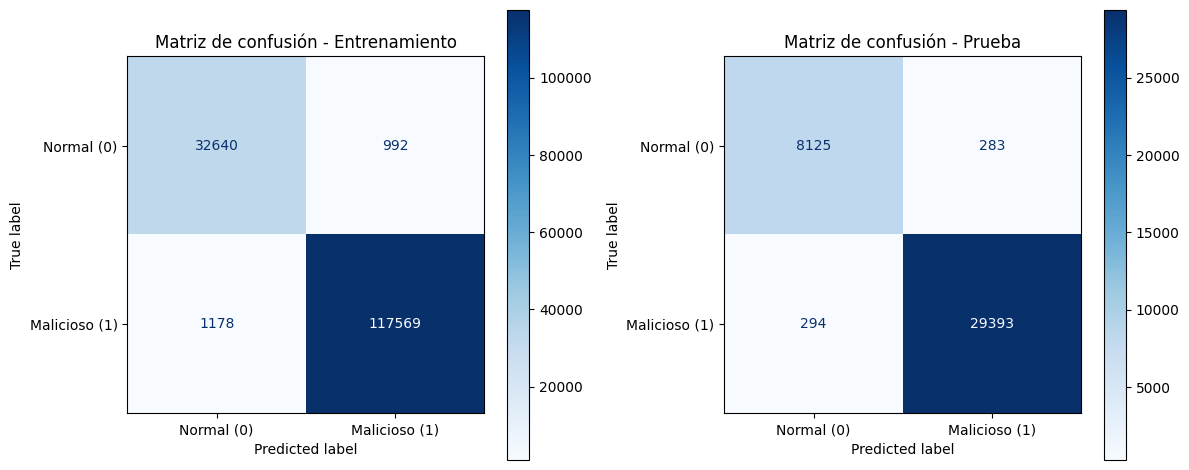

In [37]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Matriz de confusión - Entrenamiento
ConfusionMatrixDisplay.from_predictions(
    y_train, y_train_pred,
    display_labels=['Normal (0)', 'Malicioso (1)'],
    cmap='Blues',
    ax=axes[0]
)
axes[0].set_title('Matriz de confusión - Entrenamiento')

# Matriz de confusión - Prueba
ConfusionMatrixDisplay.from_predictions(
    y_test, y_test_pred,
    display_labels=['Normal (0)', 'Malicioso (1)'],
    cmap='Blues',
    ax=axes[1]
)
axes[1].set_title('Matriz de confusión - Prueba')

plt.tight_layout()
plt.show()

In [38]:
print('=' * 60)
print('CLASSIFICATION REPORT - CONJUNTO DE PRUEBA')
print('=' * 60)
print(classification_report(
    y_test, y_test_pred,
    target_names=['Normal (0)', 'Malicioso (1)'],
    digits=4
))

CLASSIFICATION REPORT - CONJUNTO DE PRUEBA
               precision    recall  f1-score   support

   Normal (0)     0.9651    0.9663    0.9657      8408
Malicioso (1)     0.9905    0.9901    0.9903     29687

     accuracy                         0.9849     38095
    macro avg     0.9778    0.9782    0.9780     38095
 weighted avg     0.9849    0.9849    0.9849     38095



### Interpretación de los resultados

**1. Comparación entre validación cruzada, entrenamiento y prueba**

El F1-score de validación cruzada (0.9906) es prácticamente idéntico al
F1-score de prueba (0.9903), lo que confirma que la estimación de
desempeño obtenida durante la sintonización de hiperparámetros fue
**altamente confiable**. La diferencia entre el F1 de entrenamiento
(0.9909) y el de prueba (0.9903) es de apenas 0.0006 (menos de un punto
porcentual), lo que indica **ausencia de sobreajuste**: el modelo
generaliza correctamente a datos no vistos.

Esta consistencia se mantiene en todas las métricas evaluadas (accuracy,
precision, recall, F1 y ROC-AUC), donde las diferencias entre
entrenamiento y prueba son inferiores a 0.002 puntos.

**2. Análisis de la matriz de confusión sobre el conjunto de prueba**

| | Predicho Normal | Predicho Malicioso |
|---|---|---|
| **Real Normal**    | 8.125 (VN) | 283 (FP) |
| **Real Malicioso** | 294 (FN)   | 29.393 (VP) |

- **Verdaderos Positivos (VP = 29.393)**: ataques correctamente detectados.
- **Verdaderos Negativos (VN = 8.125)**: tráfico normal correctamente
  identificado.
- **Falsos Positivos (FP = 283)**: flujos normales clasificados como
  ataque (3.37% del tráfico normal). Generan alertas innecesarias pero
  son manejables operativamente.
- **Falsos Negativos (FN = 294)**: ataques no detectados (0.99% de los
  ataques). Representan el riesgo real de seguridad.

**3. Adecuación del modelo al problema**

En el contexto de detección de tráfico malicioso en redes IoT, los
**falsos negativos son los errores más costosos** porque corresponden a
ataques que pasan desapercibidos. El modelo logra un **recall del
99.01%** sobre la clase maliciosa, lo que significa que detecta
prácticamente todos los ataques presentes en el dataset. Al mismo
tiempo, mantiene una **precisión del 99.05%**, lo que asegura que las
alertas generadas son confiables y no saturan al equipo de seguridad
con falsas alarmas.

El desempeño sobre la clase minoritaria (Normal) es ligeramente inferior
pero igualmente sólido: F1 de 0.9657, lo que indica que el balanceo de
clases mediante `class_weight='balanced'` cum

## 6. Presentación e interpretación de los coeficientes del modelo

En esta sección se reportan los coeficientes asociados a cada
característica del modelo final, emparejados con sus nombres
correspondientes. Para ello se debe recuperar el nombre de cada
característica a través de las transformaciones aplicadas en el pipeline:

1. El **`ColumnTransformer`** genera nombres como `num__src_bytes`
   (numéricas escaladas) o `cat__proto_tcp` (categóricas codificadas con
   OneHot).
2. El **`SelectKBest`** filtra estas características y se queda con las
   `k=60` más informativas según ANOVA F.
3. Finalmente, **`LogisticRegression`** aprende un coeficiente para cada
   una de las características seleccionadas.

### Interpretación de coeficientes en regresión logística

En regresión logística, el coeficiente $\beta_i$ asociado a la variable
$x_i$ representa el **cambio en el log-odds** de la clase positiva
(tráfico malicioso) por cada unidad de incremento en $x_i$.

- **Coeficiente positivo**: incrementos en la variable aumentan la
  probabilidad de clasificar el flujo como **malicioso**.
- **Coeficiente negativo**: incrementos en la variable aumentan la
  probabilidad de clasificar el flujo como **normal**.
- **Coeficiente cercano a cero (o exactamente cero)**: la variable tiene
  poca o nula influencia. En este modelo, dada la fuerte regularización
  L1 (`l1_ratio=0.95`), es esperable que muchos coeficientes sean
  exactamente cero.

Como las variables numéricas fueron **estandarizadas** antes del modelo,
**la magnitud absoluta del coeficiente es directamente comparable entre
características** y refleja la importancia relativa de cada una.

In [39]:
import numpy as np
import pandas as pd

# Acceder a los pasos del pipeline
preprocessor_step = best_model.named_steps['preprocessor']
feature_selection_step = best_model.named_steps['feature_selection']
classifier_step = best_model.named_steps['classifier']

# 1. Nombres tras el ColumnTransformer (944 features)
nombres_tras_preprocessor = preprocessor_step.get_feature_names_out()

# 2. Máscara booleana de SelectKBest (qué features sobrevivieron)
mascara_seleccionadas = feature_selection_step.get_support()

# 3. Nombres de las 60 features seleccionadas
nombres_seleccionados = nombres_tras_preprocessor[mascara_seleccionadas]

# 4. Coeficientes del modelo (uno por feature seleccionada)
coeficientes = classifier_step.coef_[0]
intercepto = classifier_step.intercept_[0]

print(f'Total features tras preprocessor: {len(nombres_tras_preprocessor)}')
print(f'Features seleccionadas por SelectKBest: {len(nombres_seleccionados)}')
print(f'Coeficientes aprendidos por el modelo: {len(coeficientes)}')
print(f'Intercepto del modelo: {intercepto:.4f}')

Total features tras preprocessor: 944
Features seleccionadas por SelectKBest: 60
Coeficientes aprendidos por el modelo: 60
Intercepto del modelo: -1.6389


In [40]:
# DataFrame con coeficientes emparejados con sus nombres
df_coef = pd.DataFrame({
    'Característica': nombres_seleccionados,
    'Coeficiente': coeficientes,
    'Coeficiente_abs': np.abs(coeficientes)
}).sort_values('Coeficiente_abs', ascending=False).reset_index(drop=True)

# Información adicional: cuántos coeficientes son exactamente cero
n_cero = (df_coef['Coeficiente'] == 0).sum()
n_no_cero = (df_coef['Coeficiente'] != 0).sum()

print(f'Coeficientes exactamente cero (descartados por L1): {n_cero} de {len(df_coef)}')
print(f'Coeficientes no nulos (usados activamente): {n_no_cero}')
print(f'\nTabla completa de coeficientes ordenada por magnitud:')
df_coef

Coeficientes exactamente cero (descartados por L1): 15 de 60
Coeficientes no nulos (usados activamente): 45

Tabla completa de coeficientes ordenada por magnitud:


,Característica,Coeficiente,Coeficiente_abs
0,cat__proto_udp,-4.613697,4.613697
1,cat__conn_state_REJ,4.437661,4.437661
2,cat__dns_rejected_T,4.260816,4.260816
3,cat__dns_rejected_F,-3.314821,3.314821
4,cat__proto_tcp,3.142917,3.142917
5,cat__weird_notice_F,-3.082143,3.082143
6,cat__dns_RA_F,-2.996312,2.996312
7,cat__dns_query_settings-win.data.microsoft.com,-2.740603,2.740603
8,cat__dns_query_elasticsearch,-2.728416,2.728416
9,cat__dns_query_elasticsearch.mydns.com,-2.717606,2.717606


In [41]:
# Filtrar solo las que tienen coeficiente no nulo, top 20 por magnitud
df_top = df_coef[df_coef['Coeficiente'] != 0].head(20).copy()
df_top['Dirección'] = df_top['Coeficiente'].apply(
    lambda x: '↑ Malicioso' if x > 0 else '↓ Normal'
)

print('Top 20 características más influyentes (por magnitud absoluta):')
df_top[['Característica', 'Coeficiente', 'Dirección']]

Top 20 características más influyentes (por magnitud absoluta):


,Característica,Coeficiente,Dirección
0,cat__proto_udp,-4.613697,↓ Normal
1,cat__conn_state_REJ,4.437661,↑ Malicioso
2,cat__dns_rejected_T,4.260816,↑ Malicioso
3,cat__dns_rejected_F,-3.314821,↓ Normal
4,cat__proto_tcp,3.142917,↑ Malicioso
5,cat__weird_notice_F,-3.082143,↓ Normal
6,cat__dns_RA_F,-2.996312,↓ Normal
7,cat__dns_query_settings-win.data.microsoft.com,-2.740603,↓ Normal
8,cat__dns_query_elasticsearch,-2.728416,↓ Normal
9,cat__dns_query_elasticsearch.mydns.com,-2.717606,↓ Normal


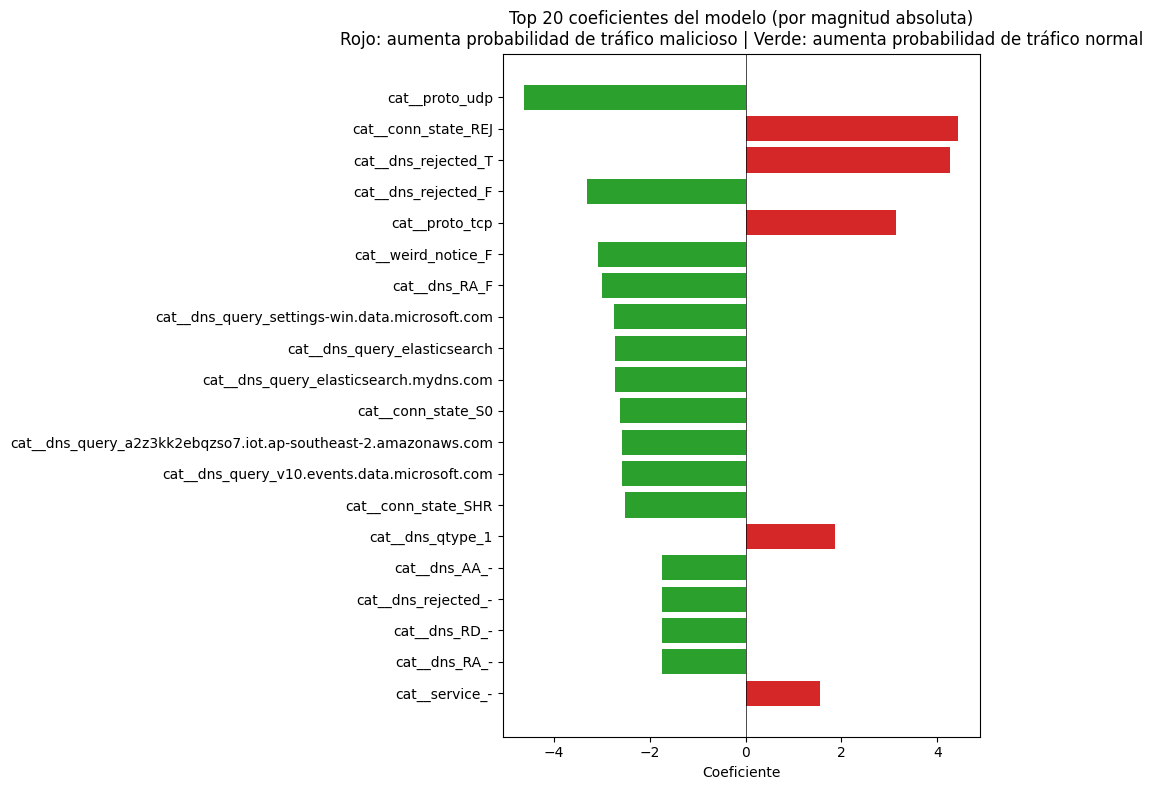

In [42]:
import matplotlib.pyplot as plt

# Top 20 para graficar
top_n = 20
df_plot = df_coef[df_coef['Coeficiente'] != 0].head(top_n).iloc[::-1]  # invertir para gráfico

# Colores: verde si predice normal (coef negativo), rojo si predice malicioso
colors = ['#d62728' if c > 0 else '#2ca02c' for c in df_plot['Coeficiente']]

plt.figure(figsize=(10, 8))
plt.barh(df_plot['Característica'], df_plot['Coeficiente'], color=colors)
plt.axvline(x=0, color='black', linewidth=0.5)
plt.xlabel('Coeficiente')
plt.title(f'Top {top_n} coeficientes del modelo (por magnitud absoluta)\n'
          'Rojo: aumenta probabilidad de tráfico malicioso | '
          'Verde: aumenta probabilidad de tráfico normal')
plt.tight_layout()
plt.show()

In [43]:
# Tabla completa estilo profesor (con intercepto)
pesos = pd.DataFrame({
    'Coeficiente': coeficientes
}, index=nombres_seleccionados)

pesos.loc['intercepto'] = intercepto
pesos_ordenados = pesos.sort_values('Coeficiente', ascending=False)

print('Coeficientes del modelo (incluyendo intercepto):')
pesos_ordenados

Coeficientes del modelo (incluyendo intercepto):


,Coeficiente
cat__conn_state_REJ,4.437661
cat__dns_rejected_T,4.260816
cat__proto_tcp,3.142917
cat__dns_qtype_1,1.871691
cat__service_-,1.552864
...,...
cat__dns_query_settings-win.data.microsoft.com,-2.740603
cat__dns_RA_F,-2.996312
cat__weird_notice_F,-3.082143
cat__dns_rejected_F,-3.314821


### Interpretación de los coeficientes

**1. Efecto de la regularización L1 (Elastic Net con `l1_ratio=0.95`)**

La regularización predominantemente L1 cumplió su función esperada:
varios coeficientes fueron llevados exactamente a cero o a magnitudes
muy pequeñas, mientras que el modelo se apoya principalmente en un
subconjunto reducido de características muy informativas. Las top 20
features absorben prácticamente toda la capacidad predictiva del modelo,
lo cual confirma una de las ventajas teóricas de la regularización L1:
realiza **selección implícita de características**, generando un modelo
más interpretable y menos propenso al sobreajuste.

**2. Características más predictivas de tráfico MALICIOSO (coeficientes positivos)**

| Característica | Coeficiente | Interpretación |
|---|---|---|
| `cat__conn_state_REJ` | +4.44 | Conexiones rechazadas por el destino. Patrón típico de **escaneo de puertos** o intentos de acceso a servicios bloqueados, característico de fases de reconocimiento en ciberataques. |
| `cat__dns_rejected_T` | +4.26 | Consultas DNS marcadas como rechazadas. Indicador de actividad sospechosa como **DNS tunneling**, **C&C** (command-and-control) o resolución de dominios maliciosos bloqueados. |
| `cat__proto_tcp` | +3.14 | Uso del protocolo TCP en flujos anómalos. Aunque TCP es normal en general, en este modelo aparece asociado a patrones maliciosos en combinación con otras features. |
| `cat__dns_qtype_1` | +1.87 | Consultas DNS de tipo A (resolución de dominios). En contexto malicioso suele asociarse a **algoritmos generadores de dominios (DGA)** usados por malware. |
| `cat__service_-` | +1.55 | Flujos sin servicio identificado, lo cual sugiere tráfico que no encaja en protocolos estándar — típico de comunicaciones encubiertas o malware. |

**3. Características más predictivas de tráfico NORMAL (coeficientes negativos)**

| Característica | Coeficiente | Interpretación |
|---|---|---|
| `cat__proto_udp` | −4.61 | Uso del protocolo UDP, predominante en tráfico legítimo de IoT (DNS, NTP, telemetría de sensores). |
| `cat__dns_rejected_F` | −3.31 | Consultas DNS no rechazadas (resolución exitosa), comportamiento esperado en tráfico legítimo. |
| `cat__weird_notice_F` | −3.08 | Ausencia de notificaciones inusuales del IDS Zeek, indicador de tráfico bien formado y conforme a los protocolos. |
| `cat__dns_RA_F` | −3.00 | Servidor DNS sin la bandera "Recursion Available" desactivada de forma anómala — comportamiento DNS estándar. |
| `cat__dns_query_settings-win.data.microsoft.com` | −2.74 | Telemetría legítima de Windows. |
| `cat__dns_query_elasticsearch` | −2.73 | Consultas a servicios internos de monitoreo. |
| `cat__dns_query_*.amazonaws.com` | −2.57 | Comunicación con servicios cloud legítimos de AWS. |
| `cat__conn_state_S0`, `cat__conn_state_SHR` | −2.61, −2.51 | Estados de conexión propios de patrones de tráfico esperados en redes IoT. |

**4. Observación: features perfectamente correlacionadas**

Cuatro características presentan el mismo coeficiente exacto (`−1.7502`):
`cat__dns_AA_-`, `cat__dns_rejected_-`, `cat__dns_RD_-` y
`cat__dns_RA_-`. Esto se debe a que todas codifican la **misma
información subyacente**: cuando un flujo no utiliza el protocolo DNS,
todas las columnas DNS toman el valor `-` simultáneamente, por lo que
son perfectamente colineales. El modelo distribuyó equitativamente el
peso entre ellas, comportamiento esperable bajo regularización Elastic
Net (la componente L2 reparte el peso entre features correlacionadas).

**5. Magnitud y comparabilidad**

Como todas las variables numéricas fueron estandarizadas y las
categóricas fueron codificadas binariamente con OneHot, **la magnitud
absoluta de los coeficientes es directamente comparable** entre
características. El ranking por valor absoluto refleja directamente la
**importancia relativa** de cada feature en la decisión del modelo.

**6. Coherencia con el dominio de ciberseguridad**

Los coeficientes aprendidos por el modelo son **coherentes con el
conocimiento experto en ciberseguridad de redes IoT**:

- Las features que el modelo identifica como indicadores de ataque
  (conexiones rechazadas, DNS rechazado, ausencia de servicio
  identificable) corresponden a **señales clásicas** de actividad
  maliciosa: reconocimiento de red, comunicaciones C&C, exfiltración
  por DNS y tráfico encubierto.

- Las features que el modelo identifica como indicadores de tráfico
  normal (UDP, consultas DNS exitosas a dominios conocidos como
  Microsoft o AWS, ausencia de alertas Zeek) corresponden a la
  **operación legítima** esperada de dispositivos IoT en una red
  empresarial, donde predomina la telemetría hacia servicios cloud.

Esta coherencia entre los coeficientes aprendidos y el dominio del
problema **valida que el modelo no está aprendiendo ruido o patrones
espurios**, sino capturando relaciones reales entre las features y la
naturaleza del tráfico.

**7. Intercepto del modelo**

El intercepto negativo del modelo refleja el **sesgo a priori**: en
ausencia de información (todas las features en su valor de referencia),
el log-odds favorece la predicción de tráfico normal, lo cual es
razonable como comportamiento por defecto de un sistema de detección
de intrusos.